# NB3 — Feature Engineering, UMAP, & Multi-Head Classification

**Upgraded**: Now supports three classification heads in parallel:
- `MultiHeadANN` — flat statistical features (original)
- `MultiHeadLSTM` — raw windowed data, bidirectional LSTM
- `MultiHeadTransformer` — raw windowed data, Transformer encoder

Set `HEAD_TYPE` below to select which model to train, or run all three for comparison.

**Pipeline flow:**
```
NB1 outputs  →  AE reconstruction  →  FeaturePipeline (ANN path)
                                    →  Raw windows    (LSTM / Transformer path)
```

> Run NB1 and NB2 first. Each saves checkpoints that this notebook loads.


## 0 — Imports & configuration

In [1]:
import sys, os, gc, pickle, warnings, logging
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')

import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

sys.path.insert(0, '..')
from models import (
    ConvAutoencoder, AETrainer,
    MultiHeadANN,         ANNTrainer,
    MultiHeadLSTM,        SequenceTrainer,
    MultiHeadTransformer,
    MCDropoutWrapper,
    DEVICE,
)
from feature_engineering import FeaturePipeline
from fault_engine        import FAULT_LABELS

PROC_DIR = '../processed_data'
CKPT_DIR = '../checkpoints'
PLOT_DIR = '../plots'

label_names = {
    0:'Nominal', 1:'Bias',     2:'Scaling', 3:'Drift',
    4:'Intermittent', 5:'Compound', 6:'MultiSensor', 7:'SystemFault'
}

# ─────────────────────────────────────────────────────────────────────
# HEAD_TYPE controls which model is trained and saved.
#   'ANN'         → original Multi-Head ANN (flat features)
#   'LSTM'        → Bidirectional LSTM on raw windows
#   'Transformer' → Transformer encoder on raw windows
#   'all'         → Train all three and compare
# ─────────────────────────────────────────────────────────────────────
HEAD_TYPE = 'all'   # change to 'LSTM' or 'Transformer' to train one only

# Whether to use AE residuals as extra input channels (LSTM / Transformer)
USE_RESIDUAL = True

print(f'Device   : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
print(f'HEAD_TYPE: {HEAD_TYPE}')
print(f'USE_RESIDUAL: {USE_RESIDUAL}')

2026-04-06 15:28:43,115 [INFO] GPU: NVIDIA RTX 4500 Ada Generation
2026-04-06 15:28:44,286 [INFO] NumExpr defaulting to 12 threads.


Device   : cuda
GPU      : NVIDIA RTX 4500 Ada Generation
HEAD_TYPE: all
USE_RESIDUAL: True


## 1 — Load NB1 + NB2 outputs

In [2]:
X_nominal = np.load(f'{PROC_DIR}/X_nominal.npy')
with open(f'{PROC_DIR}/sensor_cols.pkl', 'rb') as f:
    sensor_cols = pickle.load(f)

data = np.load(f'{PROC_DIR}/augmented_dataset.npz')
X_dataset = data['X']; y_fault = data['y_f']
y_sensor  = data['y_s']; y_mag   = data['y_m']

WINDOW_SIZE   = X_nominal.shape[1]
N_SENSORS     = X_nominal.shape[2]
N_FAULT_TYPES = 8

# Load AE
ae_model = ConvAutoencoder(
    n_sensors   = N_SENSORS,
    window_size = WINDOW_SIZE,
    base_ch=32, latent_dim=64,
).to(DEVICE)
ae_model.load_state_dict(torch.load(f'{CKPT_DIR}/autoencoder.pt', map_location=DEVICE, weights_only=True))
ae_model.eval()
ae_trainer = AETrainer(ae_model, device=DEVICE)

print(f'X_nominal   : {X_nominal.shape}  (N, T, S)')
print(f'X_dataset   : {X_dataset.shape}  (N, T, S)')
print(f'AE loaded from {CKPT_DIR}/autoencoder.pt')

2026-04-06 15:28:50,150 [INFO] AE Bottleneck: 1792 -> 64 -> 1792


X_nominal   : (120506, 50, 14)  (N, T, S)
X_dataset   : (240662, 50, 14)  (N, T, S)
AE loaded from ../checkpoints/autoencoder.pt


## 2 — Hyperparameters

In [3]:
# ── ANN (flat-feature) hyperparameters ──────────────────────────────
N_FFT_PEAKS   = 3
N_UMAP_COMP   = 2
ANN_HIDDEN    = [256, 128, 64]
ANN_EPOCHS    = 80
ANN_LR        = 5e-4

# ── LSTM hyperparameters ─────────────────────────────────────────────
LSTM_HIDDEN   = 128    # units per direction; d_model = 256
LSTM_LAYERS   = 2
LSTM_EPOCHS   = 120    # was 80 — needs more epochs to converge
LSTM_LR       = 2e-4   # was 5e-4 — lower LR avoids early stop mid-learning
LSTM_PATIENCE = 20     # was 12 — allows recovery from noisy val loss spikes
LSTM_WARMUP   = 0      # no warmup for LSTM (pure cosine)

# ── Transformer hyperparameters ──────────────────────────────────────
TF_D_MODEL    = 64
TF_NHEAD      = 4
TF_LAYERS     = 2
TF_FFN_DIM    = 256
TF_EPOCHS     = 120    # was 80 — was still learning at epoch 80
TF_LR         = 2e-4   # was 5e-4
TF_PATIENCE   = 20
TF_WARMUP     = 5      # linear warmup epochs before cosine decay

# ── Shared ───────────────────────────────────────────────────────────
BATCH_SIZE    = 512
DROPOUT_P_ANN = 0.3
DROPOUT_P_SEQ = 0.1
MC_T          = 100
MAX_FIT_SAMPLES = 100_000
RECON_BATCH   = 512

print('Hyperparameters set.')


Hyperparameters set.


## 3 — AE reconstruction of full dataset
Used by all three heads: ANN needs it for residual features; LSTM/Transformer use it as extra input channels.

In [4]:
recon_cache = f'{PROC_DIR}/augmented_dataset_with_recon.npz'

if os.path.exists(recon_cache):
    print(f'Loading cached reconstructions from {recon_cache}')
    _d = np.load(recon_cache)
    X_recon_all = _d['X_rec']
else:
    print(f'Reconstructing {len(X_dataset):,} windows in batches of {RECON_BATCH} …')
    X_recon_all = np.zeros_like(X_dataset)
    for i in tqdm(range(0, len(X_dataset), RECON_BATCH), desc='AE reconstruct'):
        X_recon_all[i:i+RECON_BATCH] = ae_trainer.reconstruct(X_dataset[i:i+RECON_BATCH])

    np.savez_compressed(
        recon_cache,
        X=X_dataset, X_rec=X_recon_all,
        y_f=y_fault, y_s=y_sensor, y_m=y_mag,
    )
    print(f'Saved {recon_cache}  ({(X_dataset.nbytes+X_recon_all.nbytes)/1e9:.2f} GB)')

print(f'X_dataset shape    : {X_dataset.shape}')
print(f'X_recon_all shape  : {X_recon_all.shape}')

Reconstructing 240,662 windows in batches of 512 …


AE reconstruct: 100%|██████████| 471/471 [00:02<00:00, 223.26it/s]


Saved ../processed_data/augmented_dataset_with_recon.npz  (1.35 GB)
X_dataset shape    : (240662, 50, 14)
X_recon_all shape  : (240662, 50, 14)


## 4a — ANN path: feature engineering + UMAP
Skip this block (or set `HEAD_TYPE='LSTM'`) if you only want the sequence models.

In [5]:
if HEAD_TYPE in ('ANN', 'all'):
    feat_pipe = FeaturePipeline(
        n_components       = N_UMAP_COMP,
        n_fft_peaks        = N_FFT_PEAKS,
        cluster_percentile = 95,
    )
    feat_pipe.projector.method = 'UMAP'

    # Subsample nominal windows for UMAP fit
    if len(X_nominal) > MAX_FIT_SAMPLES:
        idx_sub   = np.random.choice(len(X_nominal), MAX_FIT_SAMPLES, replace=False)
        X_nom_sub = X_nominal[idx_sub]
    else:
        X_nom_sub = X_nominal

    print(f'Fitting {feat_pipe.projector.method} on {len(X_nom_sub):,} nominal windows …')
    X_recon_sub = ae_trainer.reconstruct(X_nom_sub)
    feat_pipe.fit(X_nom_sub, X_recon_nominal=X_recon_sub)
    print('Pipeline fitted.')

    CHUNK = 5000
    F_chunks, Z_chunks, sev_chunks, conf_chunks = [], [], [], []

    for i in tqdm(range(0, len(X_dataset), CHUNK), desc='Feature transform'):
        xb  = X_dataset[i:i+CHUNK]
        xrb = X_recon_all[i:i+CHUNK]
        F_b, Z_b, sev_b, conf_b = feat_pipe.transform(xb, X_recon=xrb)
        F_chunks.append(F_b); Z_chunks.append(Z_b)
        sev_chunks.append(sev_b); conf_chunks.append(conf_b)
        gc.collect()

    F_all    = np.concatenate(F_chunks).astype(np.float32)
    Z_all    = np.concatenate(Z_chunks).astype(np.float32)
    sev_all  = np.concatenate(sev_chunks).astype(np.float32)
    conf_all = np.concatenate(conf_chunks).astype(np.float32)

    np.savez_compressed(
        f'{PROC_DIR}/final_manifold_features.npz',
        F=F_all, Z=Z_all, sev=sev_all, conf=conf_all,
        y_f=y_fault, y_s=y_sensor, y_m=y_mag,
    )
    with open(f'{CKPT_DIR}/feature_pipeline.pkl', 'wb') as f:
        pickle.dump(feat_pipe, f)

    print(f'F_all shape : {F_all.shape}  (ANN input features)')
    print(f'Saved final_manifold_features.npz and feature_pipeline.pkl')
else:
    print('Skipping ANN feature engineering (HEAD_TYPE is not ANN/all).')

Fitting UMAP on 100,000 nominal windows …


2026-04-06 15:33:19,863 [INFO] ManifoldProjector: fitted UMAP (n_comp=2)
2026-04-06 15:33:20,069 [INFO] NominalCluster fitted | center=[2.630121   0.06313915] | R_95=2.2430


Pipeline fitted.


Feature transform: 100%|██████████| 49/49 [08:06<00:00,  9.92s/it]


F_all shape : (240662, 196)  (ANN input features)
Saved final_manifold_features.npz and feature_pipeline.pkl


## 4b — UMAP manifold plot (ANN path only)

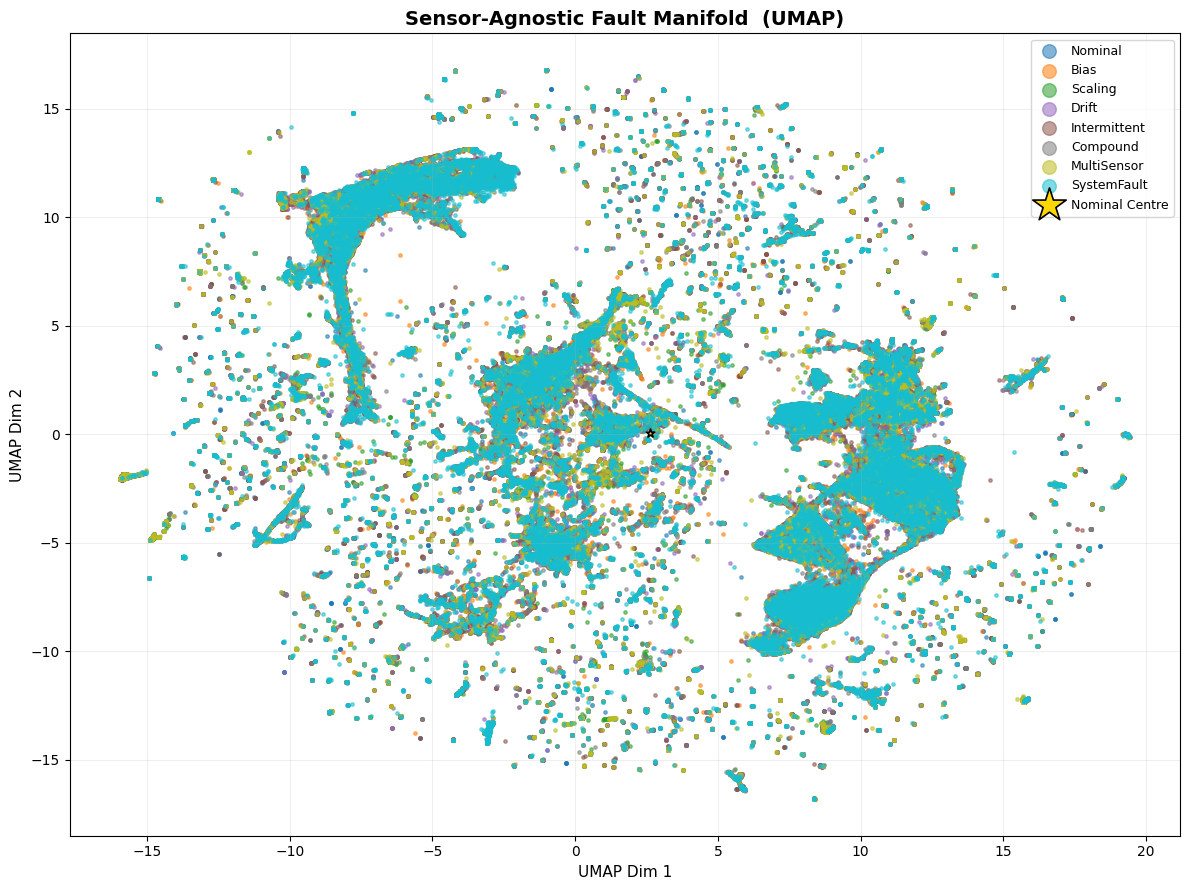

In [6]:
if HEAD_TYPE in ('ANN', 'all') and 'Z_all' in dir():
    cmap_ = plt.cm.get_cmap('tab10', 8)
    fig, ax = plt.subplots(figsize=(12, 9))
    for lbl in np.unique(y_fault):
        m = y_fault == lbl
        ax.scatter(Z_all[m, 0], Z_all[m, 1],
                   c=[cmap_(lbl)], label=label_names.get(lbl, str(lbl)),
                   s=6, alpha=0.55, rasterized=True)
    cx, cy = feat_pipe.cluster.center_
    ax.scatter(cx, cy, marker='*', s=40, c='gold', edgecolors='black',
               linewidths=1.2, zorder=10, label='Nominal Centre')
    ax.set_xlabel(f'{feat_pipe.projector.method} Dim 1', fontsize=11)
    ax.set_ylabel(f'{feat_pipe.projector.method} Dim 2', fontsize=11)
    ax.set_title(f'Sensor-Agnostic Fault Manifold  ({feat_pipe.projector.method})', fontsize=14, fontweight='bold')
    ax.legend(markerscale=4, fontsize=9); ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/nb3_manifold.png', dpi=130)
    plt.show()

## 5a — Train Multi-Head ANN  (flat features)

In [7]:
ann_val_losses = None

if HEAD_TYPE in ('ANN', 'all'):
    n_features = F_all.shape[1]
    print(f'ANN input features : {n_features}')

    ann_model = MultiHeadANN(
        in_features   = n_features,
        n_fault_types = N_FAULT_TYPES,
        n_sensors     = len(sensor_cols),
        hidden_dims   = ANN_HIDDEN,
        dropout_p     = DROPOUT_P_ANN,
    )
    print(f'ANN parameters : {sum(p.numel() for p in ann_model.parameters()):,}')

    ann_trainer = ANNTrainer(ann_model, lr=ANN_LR, device=DEVICE)
    ann_val_losses = ann_trainer.fit(
        F_all, y_fault, y_sensor, y_mag,
        epochs     = ANN_EPOCHS,
        batch_size = BATCH_SIZE,
    )

    torch.save(ann_model.state_dict(), f'{CKPT_DIR}/ann_multihead.pt')
    print(f'Multi-Head ANN saved → {CKPT_DIR}/ann_multihead.pt')
    print(f'Best val loss : {min(ann_val_losses):.4f}')
else:
    print('Skipping ANN training.')

ANN input features : 196
ANN parameters : 96,023


2026-04-06 15:42:31,418 [INFO] ANN Epoch  10/80 | val_loss=2.0380
2026-04-06 15:43:22,952 [INFO] ANN Epoch  20/80 | val_loss=1.8477
2026-04-06 15:44:16,234 [INFO] ANN Epoch  30/80 | val_loss=1.7712
2026-04-06 15:45:09,948 [INFO] ANN Epoch  40/80 | val_loss=1.7017
2026-04-06 15:46:04,049 [INFO] ANN Epoch  50/80 | val_loss=1.6736
2026-04-06 15:46:57,854 [INFO] ANN Epoch  60/80 | val_loss=1.6567
2026-04-06 15:47:51,632 [INFO] ANN Epoch  70/80 | val_loss=1.6072
2026-04-06 15:48:44,763 [INFO] ANN Epoch  80/80 | val_loss=1.5899


Multi-Head ANN saved → ../checkpoints/ann_multihead.pt
Best val loss : 1.5838


## 5b — Train Multi-Head LSTM  (raw windows)

In [8]:
lstm_val_losses = None

if HEAD_TYPE in ('LSTM', 'all'):
    lstm_model = MultiHeadLSTM(
        n_sensors     = N_SENSORS,
        hidden_size   = LSTM_HIDDEN,
        num_layers    = LSTM_LAYERS,
        n_fault_types = N_FAULT_TYPES,
        dropout_p     = DROPOUT_P_ANN,
        use_residual  = USE_RESIDUAL,
    )
    print(f'LSTM parameters : {sum(p.numel() for p in lstm_model.parameters()):,}')
    print(f'Input channels  : {N_SENSORS * 2 if USE_RESIDUAL else N_SENSORS}')

    lstm_trainer = SequenceTrainer(
        lstm_model,
        lr           = LSTM_LR,
        device       = DEVICE,
        warmup_epochs= LSTM_WARMUP,
    )
    lstm_val_losses = lstm_trainer.fit(
        X_dataset, y_fault, y_sensor, y_mag,
        X_recon    = X_recon_all if USE_RESIDUAL else None,
        epochs     = LSTM_EPOCHS,
        batch_size = BATCH_SIZE,
        patience   = LSTM_PATIENCE,
    )

    torch.save(lstm_model.state_dict(), f'{CKPT_DIR}/lstm_multihead.pt')
    print(f'Multi-Head LSTM saved → {CKPT_DIR}/lstm_multihead.pt')
    print(f'Best val loss : {min(lstm_val_losses):.4f}')
else:
    print('Skipping LSTM training.')


LSTM parameters : 678,871
Input channels  : 28


2026-04-06 15:50:30,487 [INFO] MultiHeadLSTM Epoch  10/120 | train=2.4801 | val=2.5554
2026-04-06 15:52:12,587 [INFO] MultiHeadLSTM Epoch  20/120 | train=2.1667 | val=2.5723
2026-04-06 15:53:54,456 [INFO] MultiHeadLSTM Epoch  30/120 | train=1.9199 | val=2.1874
2026-04-06 15:55:36,626 [INFO] MultiHeadLSTM Epoch  40/120 | train=1.7106 | val=2.2642
2026-04-06 15:57:18,711 [INFO] MultiHeadLSTM Epoch  50/120 | train=1.5688 | val=1.8705
2026-04-06 15:59:00,950 [INFO] MultiHeadLSTM Epoch  60/120 | train=1.4566 | val=1.6986
2026-04-06 16:00:43,697 [INFO] MultiHeadLSTM Epoch  70/120 | train=1.3597 | val=1.6212
2026-04-06 16:02:21,516 [INFO] MultiHeadLSTM Epoch  80/120 | train=1.2630 | val=1.4273
2026-04-06 16:03:57,167 [INFO] MultiHeadLSTM Epoch  90/120 | train=1.1912 | val=1.3306
2026-04-06 16:05:33,791 [INFO] MultiHeadLSTM Epoch 100/120 | train=1.1305 | val=1.2608
2026-04-06 16:07:08,519 [INFO] MultiHeadLSTM Epoch 110/120 | train=1.0924 | val=1.2208
2026-04-06 16:08:43,103 [INFO] MultiHeadLST

Multi-Head LSTM saved → ../checkpoints/lstm_multihead.pt
Best val loss : 1.2107


## 5c — Train Multi-Head Transformer  (raw windows)

In [9]:
tf_val_losses = None

if HEAD_TYPE in ('Transformer', 'all'):
    tf_model = MultiHeadTransformer(
        n_sensors      = N_SENSORS,
        d_model        = TF_D_MODEL,
        nhead          = TF_NHEAD,
        num_layers     = TF_LAYERS,
        dim_feedforward= TF_FFN_DIM,
        n_fault_types  = N_FAULT_TYPES,
        dropout_p      = DROPOUT_P_SEQ,
        use_residual   = USE_RESIDUAL,
        store_attn     = True,
    )
    print(f'Transformer parameters : {sum(p.numel() for p in tf_model.parameters()):,}')
    print(f'Input channels         : {N_SENSORS * 2 if USE_RESIDUAL else N_SENSORS}')

    tf_trainer = SequenceTrainer(
        tf_model,
        lr           = TF_LR,
        device       = DEVICE,
        warmup_epochs= TF_WARMUP,   # 5-epoch linear warmup before cosine decay
    )
    tf_val_losses = tf_trainer.fit(
        X_dataset, y_fault, y_sensor, y_mag,
        X_recon    = X_recon_all if USE_RESIDUAL else None,
        epochs     = TF_EPOCHS,
        batch_size = BATCH_SIZE,
        patience   = TF_PATIENCE,
    )

    torch.save(tf_model.state_dict(), f'{CKPT_DIR}/transformer_multihead.pt')
    print(f'Multi-Head Transformer saved → {CKPT_DIR}/transformer_multihead.pt')
    print(f'Best val loss : {min(tf_val_losses):.4f}')
else:
    print('Skipping Transformer training.')


Transformer parameters : 105,879
Input channels         : 28


2026-04-06 16:10:21,604 [INFO] MultiHeadTransformer Epoch  10/120 | train=2.4204 | val=2.6250
2026-04-06 16:12:03,071 [INFO] MultiHeadTransformer Epoch  20/120 | train=2.2334 | val=2.4995
2026-04-06 16:13:43,823 [INFO] MultiHeadTransformer Epoch  30/120 | train=2.1091 | val=2.3433
2026-04-06 16:15:24,373 [INFO] MultiHeadTransformer Epoch  40/120 | train=2.0095 | val=2.2246
2026-04-06 16:17:05,211 [INFO] MultiHeadTransformer Epoch  50/120 | train=1.9300 | val=2.0506
2026-04-06 16:18:46,027 [INFO] MultiHeadTransformer Epoch  60/120 | train=1.8642 | val=2.0820
2026-04-06 16:20:26,961 [INFO] MultiHeadTransformer Epoch  70/120 | train=1.8087 | val=1.9216
2026-04-06 16:22:08,013 [INFO] MultiHeadTransformer Epoch  80/120 | train=1.7659 | val=1.9502
2026-04-06 16:23:48,914 [INFO] MultiHeadTransformer Epoch  90/120 | train=1.7324 | val=1.8560
2026-04-06 16:25:30,303 [INFO] MultiHeadTransformer Epoch 100/120 | train=1.7116 | val=1.8730
2026-04-06 16:27:11,668 [INFO] MultiHeadTransformer Epoch 11

Multi-Head Transformer saved → ../checkpoints/transformer_multihead.pt
Best val loss : 1.8186


## 6 — Training curve comparison

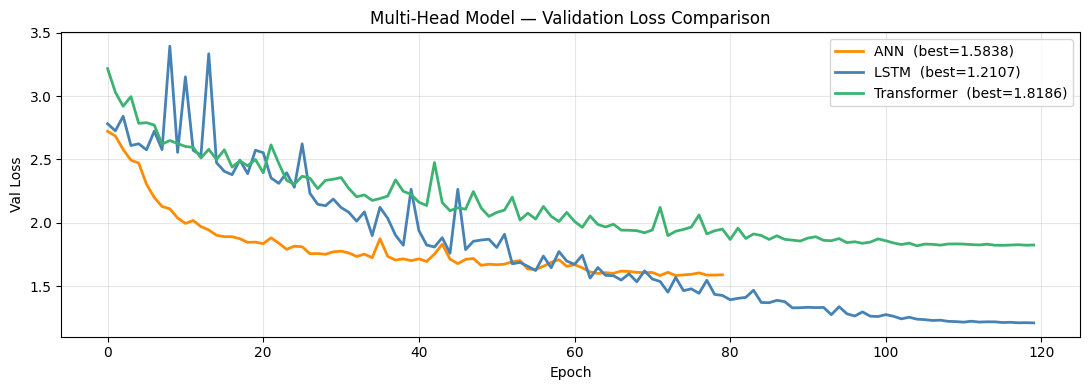

Best val losses: {'ANN': '1.5838', 'LSTM': '1.2107', 'Transformer': '1.8186'}


In [10]:
curves = {
    'ANN':         (ann_val_losses,  'darkorange'),
    'LSTM':        (lstm_val_losses, 'steelblue'),
    'Transformer': (tf_val_losses,   'mediumseagreen'),
}

active = {k: v for k, v in curves.items() if v[0] is not None}
if active:
    fig, ax = plt.subplots(figsize=(11, 4))
    for name, (losses, color) in active.items():
        ax.plot(losses, lw=2, color=color, label=f'{name}  (best={min(losses):.4f})')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Val Loss')
    ax.set_title('Multi-Head Model — Validation Loss Comparison')
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/nb3_training_curve_comparison.png', dpi=120)
    plt.show()
    print('Best val losses:', {k: f'{min(v[0]):.4f}' for k, v in active.items()})

## 7 — MC Dropout confidence comparison

In [11]:
from sklearn.model_selection import train_test_split

# Stratified test sampling — guarantees every class is represented
# (pure random sampling left SystemFault with 0 support in previous run)
_, idx_test = train_test_split(
    np.arange(len(X_dataset)),
    test_size   = min(500, len(X_dataset)),
    stratify    = y_fault,
    random_state= 42,
)
idx_test = np.array(idx_test)

# Prepare inputs for each model type
X_raw_test  = X_dataset[idx_test]
X_rec_test  = X_recon_all[idx_test]
true_mag    = y_mag[idx_test]

# Sequence input — with or without residual channels
if USE_RESIDUAL:
    X_seq_test = np.concatenate([X_raw_test, np.abs(X_raw_test - X_rec_test)], axis=-1)
else:
    X_seq_test = X_raw_test

seq_t = torch.from_numpy(X_seq_test).float().to(DEVICE)

mc_results = {}

if HEAD_TYPE in ('ANN', 'all') and ann_val_losses is not None:
    F_test = torch.from_numpy(F_all[idx_test]).float().to(DEVICE)
    mc_ann = MCDropoutWrapper(ann_model, T=MC_T)
    mc_results['ANN'] = {
        'fault': mc_ann.predict(F_test, head='fault'),
        'mag':   mc_ann.predict(F_test, head='magnitude'),
    }

if HEAD_TYPE in ('LSTM', 'all') and lstm_val_losses is not None:
    mc_lstm = MCDropoutWrapper(lstm_model, T=MC_T)
    mc_results['LSTM'] = {
        'fault': mc_lstm.predict(seq_t, head='fault'),
        'mag':   mc_lstm.predict(seq_t, head='magnitude'),
    }

if HEAD_TYPE in ('Transformer', 'all') and tf_val_losses is not None:
    mc_tf = MCDropoutWrapper(tf_model, T=MC_T)
    mc_results['Transformer'] = {
        'fault': mc_tf.predict(seq_t, head='fault'),
        'mag':   mc_tf.predict(seq_t, head='magnitude'),
    }

print(f'MC results collected for: {list(mc_results.keys())}')
print(f'Test set class distribution (stratified):')
for l, c in zip(*np.unique(y_fault[idx_test], return_counts=True)):
    print(f'  {label_names.get(l, str(l)):15s}: {c:>5,}')


MC results collected for: ['ANN', 'LSTM', 'Transformer']
Test set class distribution (stratified):
  Nominal        :    62
  Bias           :    62
  Scaling        :    62
  Drift          :    63
  Intermittent   :    62
  Compound       :    63
  MultiSensor    :    63
  SystemFault    :    63


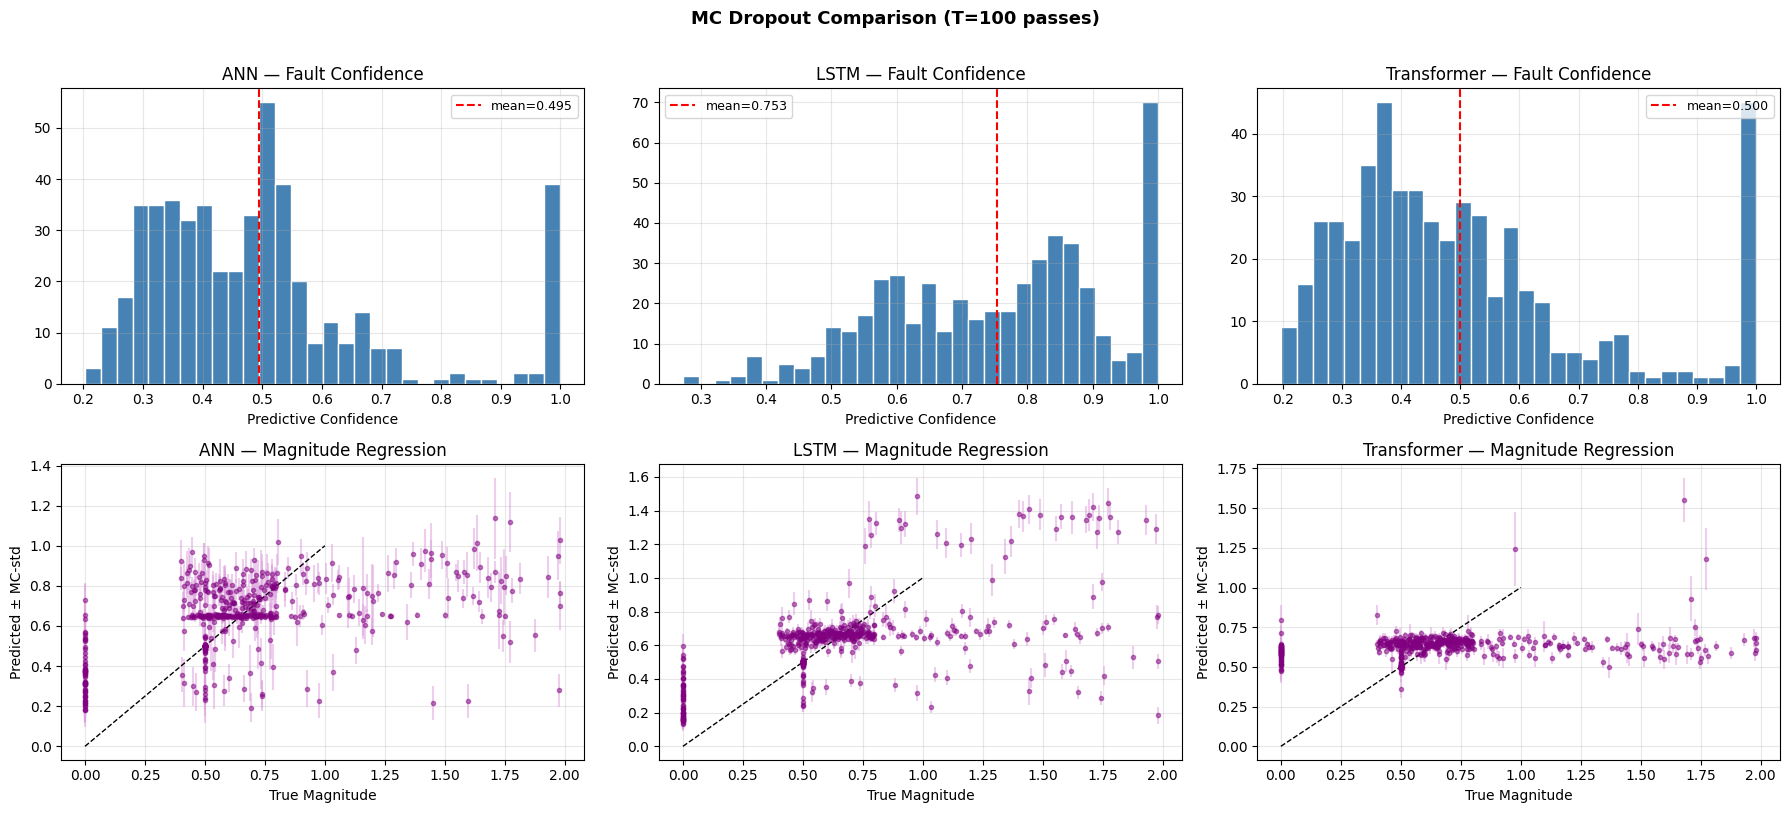


Mean predictive confidence:
  ANN         : 0.495  (min=0.203, max=1.000)
  LSTM        : 0.753  (min=0.273, max=1.000)
  Transformer : 0.500  (min=0.197, max=1.000)


In [12]:
n_models = len(mc_results)
if n_models > 0:
    fig, axes = plt.subplots(2, n_models, figsize=(6*n_models, 8), squeeze=False)

    for col, (name, res) in enumerate(mc_results.items()):
        # Row 0: fault confidence histogram
        conf = res['fault']['confidence'].cpu().numpy()
        axes[0, col].hist(conf, bins=30, color='steelblue', edgecolor='white')
        axes[0, col].set_xlabel('Predictive Confidence')
        axes[0, col].set_title(f'{name} — Fault Confidence')
        axes[0, col].axvline(conf.mean(), color='red', ls='--', lw=1.5,
                             label=f'mean={conf.mean():.3f}')
        axes[0, col].legend(fontsize=9)

        # Row 1: magnitude prediction vs truth
        m_mean = res['mag']['mean_mag'].cpu().numpy()
        m_std  = res['mag']['std_mag'].cpu().numpy()
        axes[1, col].errorbar(true_mag, m_mean, yerr=m_std, fmt='o', ms=3,
                              color='purple', ecolor='plum', alpha=0.5)
        axes[1, col].plot([0, 1], [0, 1], 'k--', lw=1)
        axes[1, col].set_xlabel('True Magnitude')
        axes[1, col].set_ylabel('Predicted ± MC-std')
        axes[1, col].set_title(f'{name} — Magnitude Regression')
        for ax in axes[:, col]: ax.grid(alpha=0.3)

    plt.suptitle('MC Dropout Comparison (T=100 passes)', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/nb3_mc_dropout_comparison.png', dpi=120, bbox_inches='tight')
    plt.show()

    print('\nMean predictive confidence:')
    for name, res in mc_results.items():
        conf = res['fault']['confidence'].cpu().numpy()
        print(f'  {name:12s}: {conf.mean():.3f}  (min={conf.min():.3f}, max={conf.max():.3f})')

## 8 — Transformer attention map (Transformer head only)
Visualises which timesteps the model attended to for a single test window.

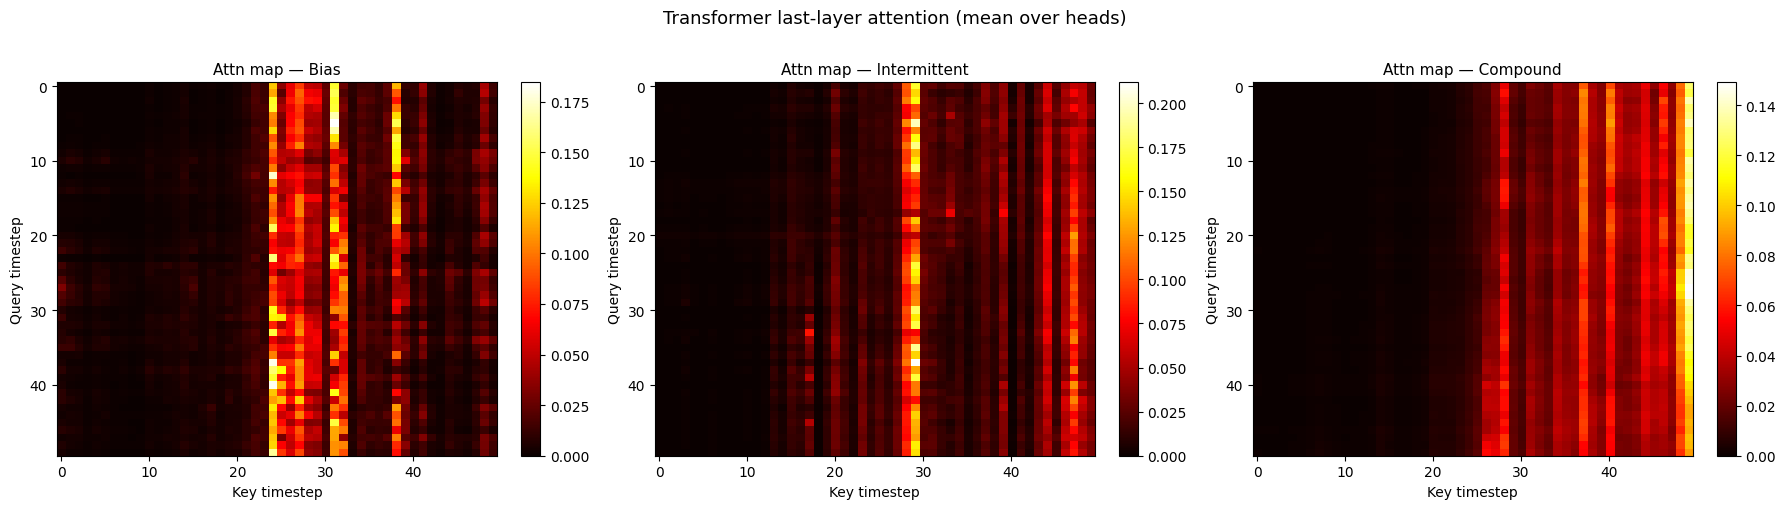

In [13]:
if HEAD_TYPE in ('Transformer', 'all') and tf_val_losses is not None:

    tf_model.eval()
    tf_model.store_attn = True

    # Pick a few examples of each fault class
    N_EXAMPLES = min(3, len(idx_test))
    example_idx = idx_test[:N_EXAMPLES]

    with torch.no_grad():
        single = seq_t[:N_EXAMPLES]   # (N_EXAMPLES, T, S[*2])
        _ = tf_model(single)

    if tf_model.last_attn_weights is not None:
        attn = tf_model.last_attn_weights.numpy()   # (N_EXAMPLES, T, T)

        fig, axes = plt.subplots(1, N_EXAMPLES, figsize=(6*N_EXAMPLES, 5))
        if N_EXAMPLES == 1: axes = [axes]

        for i, ax in enumerate(axes):
            im = ax.imshow(attn[i], aspect='auto', cmap='hot', vmin=0)
            fault_lbl = label_names.get(int(y_fault[example_idx[i]]), '?')
            ax.set_title(f'Attn map — {fault_lbl}', fontsize=11)
            ax.set_xlabel('Key timestep'); ax.set_ylabel('Query timestep')
            plt.colorbar(im, ax=ax, fraction=0.046)

        plt.suptitle('Transformer last-layer attention (mean over heads)', fontsize=13, y=1.01)
        plt.tight_layout()
        plt.savefig(f'{PLOT_DIR}/nb3_transformer_attention.png', dpi=130, bbox_inches='tight')
        plt.show()
    else:
        print('Attention weights not captured — check store_attn=True.')

## 9 — Per-class accuracy comparison


  ANN  — Classification Report
              precision    recall  f1-score   support

     Nominal       0.59      0.94      0.72        62
        Bias       0.41      0.53      0.46        62
     Scaling       0.54      0.98      0.70        62
       Drift       0.62      0.63      0.63        63
Intermittent       0.48      0.48      0.48        62
    Compound       0.00      0.00      0.00        63
 MultiSensor       0.60      0.19      0.29        63
 SystemFault       0.92      0.90      0.91        63

    accuracy                           0.58       500
   macro avg       0.52      0.58      0.52       500
weighted avg       0.52      0.58      0.52       500


  LSTM  — Classification Report
              precision    recall  f1-score   support

     Nominal       0.66      0.95      0.78        62
        Bias       0.76      1.00      0.86        62
     Scaling       0.67      1.00      0.81        62
       Drift       0.70      0.98      0.82        63
Intermittent 

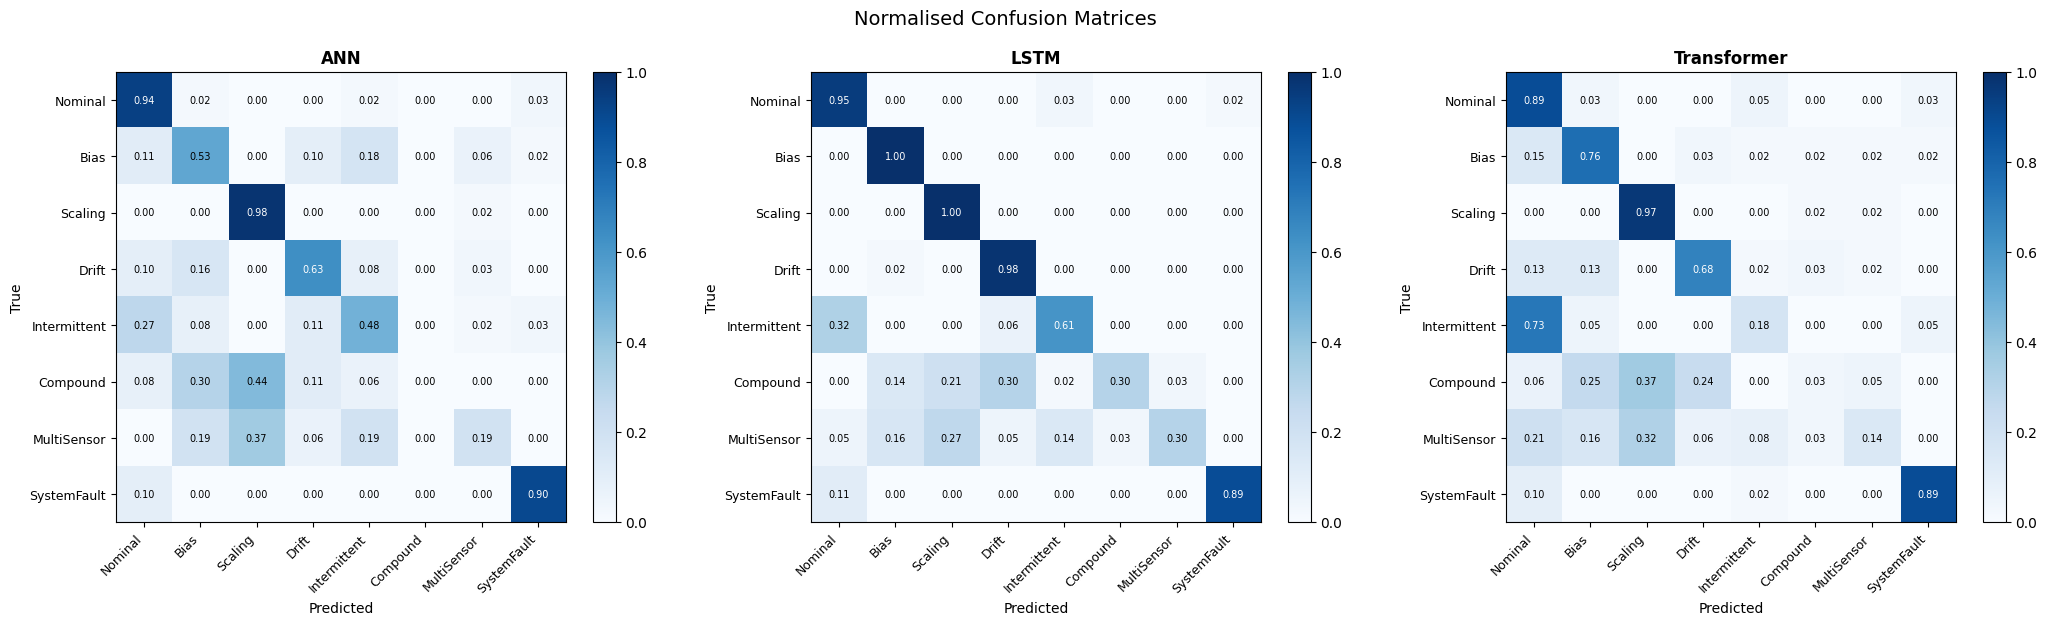

In [14]:
true_labels = y_fault[idx_test]

model_preds = {}

for name, res in mc_results.items():
    preds = res['fault']['pred_class'].cpu().numpy()
    model_preds[name] = preds

if model_preds:
    from sklearn.metrics import classification_report, confusion_matrix
    import itertools

    for name, preds in model_preds.items():
        print(f'\n{"="*55}')
        print(f'  {name}  — Classification Report')
        print(f'{"="*55}')
        print(classification_report(
            true_labels, preds,
            labels      = list(range(N_FAULT_TYPES)),
            target_names= [label_names[i] for i in range(N_FAULT_TYPES)],
            zero_division= 0,
        ))

    # Side-by-side confusion matrices
    n_models    = len(model_preds)
    class_names = [label_names[i] for i in range(N_FAULT_TYPES)]
    fig, axes   = plt.subplots(1, n_models, figsize=(7*n_models, 6), squeeze=False)

    for col, (name, preds) in enumerate(model_preds.items()):
        # labels= forces 8x8 even when some classes have 0 support in test sample
        cm      = confusion_matrix(true_labels, preds, labels=list(range(N_FAULT_TYPES)))
        cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True).clip(min=1)
        im = axes[0, col].imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
        axes[0, col].set_xticks(range(len(class_names)))
        axes[0, col].set_yticks(range(len(class_names)))
        axes[0, col].set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
        axes[0, col].set_yticklabels(class_names, fontsize=9)
        axes[0, col].set_title(f'{name}', fontsize=12, fontweight='bold')
        axes[0, col].set_xlabel('Predicted'); axes[0, col].set_ylabel('True')
        for i, j in itertools.product(range(len(class_names)), repeat=2):
            axes[0, col].text(j, i, f'{cm_norm[i,j]:.2f}',
                              ha='center', va='center', fontsize=7,
                              color='white' if cm_norm[i,j] > 0.6 else 'black')
        plt.colorbar(im, ax=axes[0, col], fraction=0.046)

    plt.suptitle('Normalised Confusion Matrices', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/nb3_confusion_comparison.png', dpi=130, bbox_inches='tight')
    plt.show()


## 10 — Save metadata for NB4 (SHAP) and NB5 (Diagnosis)

In [15]:
import json

# Save which model was trained and its config for downstream notebooks
meta = {
    'head_type'     : HEAD_TYPE,
    'use_residual'  : USE_RESIDUAL,
    'n_sensors'     : N_SENSORS,
    'window_size'   : WINDOW_SIZE,
    'n_fault_types' : N_FAULT_TYPES,
    'n_sensor_cols' : len(sensor_cols),
    'lstm_config'   : {
        'hidden_size': LSTM_HIDDEN, 'num_layers': LSTM_LAYERS,
        'dropout_p': DROPOUT_P_ANN,
    } if HEAD_TYPE in ('LSTM', 'all') else None,
    'transformer_config': {
        'd_model': TF_D_MODEL, 'nhead': TF_NHEAD,
        'num_layers': TF_LAYERS, 'dim_feedforward': TF_FFN_DIM,
        'dropout_p': DROPOUT_P_SEQ,
    } if HEAD_TYPE in ('Transformer', 'all') else None,
    'best_val_losses': {
        k: float(min(v[0])) for k, v in [
            ('ANN', (ann_val_losses,)),
            ('LSTM', (lstm_val_losses,)),
            ('Transformer', (tf_val_losses,)),
        ] if v[0] is not None
    },
}

with open(f'{CKPT_DIR}/nb3_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved nb3_meta.json')
print(json.dumps(meta, indent=2))
print('\n✓ NB3 complete — Proceed to NB4_SHAP.ipynb')

Saved nb3_meta.json
{
  "head_type": "all",
  "use_residual": true,
  "n_sensors": 14,
  "window_size": 50,
  "n_fault_types": 8,
  "n_sensor_cols": 14,
  "lstm_config": {
    "hidden_size": 128,
    "num_layers": 2,
    "dropout_p": 0.3
  },
  "transformer_config": {
    "d_model": 64,
    "nhead": 4,
    "num_layers": 2,
    "dim_feedforward": 256,
    "dropout_p": 0.1
  },
  "best_val_losses": {
    "ANN": 1.583757996559143,
    "LSTM": 1.2107446193695068,
    "Transformer": 1.8185808658599854
  }
}

✓ NB3 complete — Proceed to NB4_SHAP.ipynb


---
## ↻ Reload Block
Run this cell if the kernel was restarted mid-session.

In [16]:
# ── Run this block only if kernel was restarted ──────────────────────────────
import sys, os, gc, pickle, warnings, json
import numpy as np, torch
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')
from models import (
    ConvAutoencoder, AETrainer,
    MultiHeadANN, ANNTrainer,
    MultiHeadLSTM, MultiHeadTransformer,
    SequenceTrainer, MCDropoutWrapper, DEVICE,
)
from feature_engineering import FeaturePipeline
from fault_engine        import FAULT_LABELS

PROC_DIR = '../processed_data'; CKPT_DIR = '../checkpoints'; PLOT_DIR = '../plots'
label_names = {0:'Nominal',1:'Bias',2:'Scaling',3:'Drift',
               4:'Intermittent',5:'Compound',6:'MultiSensor',7:'SystemFault'}

X_nominal = np.load(f'{PROC_DIR}/X_nominal.npy')
with open(f'{PROC_DIR}/sensor_cols.pkl', 'rb') as f: sensor_cols = pickle.load(f)

N_SENSORS     = X_nominal.shape[2]
WINDOW_SIZE   = X_nominal.shape[1]
N_FAULT_TYPES = 8

# Load meta to know what was trained
with open(f'{CKPT_DIR}/nb3_meta.json') as f: meta = json.load(f)
HEAD_TYPE    = meta['head_type']
USE_RESIDUAL = meta['use_residual']

# AE
ae_model = ConvAutoencoder(n_sensors=N_SENSORS, window_size=WINDOW_SIZE, base_ch=32, latent_dim=64).to(DEVICE)
ae_model.load_state_dict(torch.load(f'{CKPT_DIR}/autoencoder.pt', map_location=DEVICE, weights_only=True))
ae_model.eval()
ae_trainer = AETrainer(ae_model, device=DEVICE)

# ANN
if HEAD_TYPE in ('ANN', 'all') and os.path.exists(f'{CKPT_DIR}/ann_multihead.pt'):
    _d = np.load(f'{PROC_DIR}/final_manifold_features.npz')
    F_all    = _d['F']; Z_all = _d['Z']
    sev_all  = _d['sev']; conf_all = _d['conf']
    y_fault  = _d['y_f']; y_sensor = _d['y_s']; y_mag = _d['y_m']
    with open(f'{CKPT_DIR}/feature_pipeline.pkl', 'rb') as f: feat_pipe = pickle.load(f)
    ann_model = MultiHeadANN(in_features=F_all.shape[1], n_fault_types=N_FAULT_TYPES,
                              n_sensors=len(sensor_cols), hidden_dims=[256,128,64], dropout_p=0.3)
    ann_model.load_state_dict(torch.load(f'{CKPT_DIR}/ann_multihead.pt', map_location=DEVICE, weights_only=True))
    ann_model.to(DEVICE).eval()

# Dataset (for sequence models)
_raw = np.load(f'{PROC_DIR}/augmented_dataset_with_recon.npz')
X_dataset   = _raw['X']; X_recon_all = _raw['X_rec']
if HEAD_TYPE not in ('ANN', 'all'):
    y_fault = _raw['y_f']; y_sensor = _raw['y_s']; y_mag = _raw['y_m']

# LSTM
if HEAD_TYPE in ('LSTM', 'all') and os.path.exists(f'{CKPT_DIR}/lstm_multihead.pt'):
    cfg = meta['lstm_config']
    lstm_model = MultiHeadLSTM(n_sensors=N_SENSORS, hidden_size=cfg['hidden_size'],
                                num_layers=cfg['num_layers'], n_fault_types=N_FAULT_TYPES,
                                dropout_p=cfg['dropout_p'], use_residual=USE_RESIDUAL)
    lstm_model.load_state_dict(torch.load(f'{CKPT_DIR}/lstm_multihead.pt', map_location=DEVICE, weights_only=True))
    lstm_model.to(DEVICE).eval()

# Transformer
if HEAD_TYPE in ('Transformer', 'all') and os.path.exists(f'{CKPT_DIR}/transformer_multihead.pt'):
    cfg = meta['transformer_config']
    tf_model = MultiHeadTransformer(n_sensors=N_SENSORS, d_model=cfg['d_model'],
                                     nhead=cfg['nhead'], num_layers=cfg['num_layers'],
                                     dim_feedforward=cfg['dim_feedforward'],
                                     n_fault_types=N_FAULT_TYPES, dropout_p=cfg['dropout_p'],
                                     use_residual=USE_RESIDUAL, store_attn=True)
    tf_model.load_state_dict(torch.load(f'{CKPT_DIR}/transformer_multihead.pt', map_location=DEVICE, weights_only=True))
    tf_model.to(DEVICE).eval()

print('✓ All models & data reloaded')
print(f'  HEAD_TYPE={HEAD_TYPE}  USE_RESIDUAL={USE_RESIDUAL}')

2026-04-06 16:28:58,909 [INFO] AE Bottleneck: 1792 -> 64 -> 1792


✓ All models & data reloaded
  HEAD_TYPE=all  USE_RESIDUAL=True
